# Hyperparameter Optimization — Grid, Random, and Bayesian (Optuna)

**Author:** Shivani Bokka
**Datasets:** Adult Census Income (classification), Ames Housing (regression)
**Goal:** Learn how to *tune* a model properly — from brute-force grids to smart Bayesian search

---

## What Is This Notebook About?

Every model has **knobs** you set *before* training — the number of trees, how deep they grow, the
learning rate, and so on. These are called **hyperparameters** (to distinguish them from the model's
*parameters*, which are learned from data). Picking good values can be the difference between a mediocre
model and a great one.

This notebook is a **complete, plain-English tour of hyperparameter optimization (HPO)**. We start with
the simplest possible approach (try everything) and build up to the smart, modern approach used in
industry and Kaggle competitions: **Bayesian optimization with [Optuna](https://optuna.org/)**.

> **The one-sentence idea:** instead of guessing hyperparameters or brute-forcing every combination,
> we let an algorithm *learn from each attempt* and spend its next attempts where they're most likely to pay off.

---

## What You Will Learn

| # | Section | Key Idea |
|---|---------|----------|
| 1 | Imports and Setup | Libraries, including Optuna |
| 2 | Load Data | Adult (classification) + Ames (regression) |
| 3 | Why Tuning Matters | A default model vs a tuned one |
| 4 | Grid Search | Try every combination — simple but expensive |
| 5 | Random Search | Try random combinations — surprisingly better |
| 6 | Bayesian Optimization (Optuna) | Learn from each trial, search smartly |
| 7 | Designing the Search Space | log-scale vs linear, categorical choices |
| 8 | Pruning | Stop hopeless trials early to save time |
| 9 | Parameter Importance | Which knobs actually mattered? |
| 10 | Apply the Best Params | Tuned vs default, head to head |
| 11 | Regression Example | Tuning LightGBM on Ames house prices |
| 12 | Summary | Decision guide + common mistakes |

---

## A Note on Reproducibility

We fix `random_state=42` (and Optuna's `seed=42`) everywhere, so re-running gives the same numbers.
Your exact values may differ slightly across library versions, but every *pattern* and conclusion holds.

---


## Step 1 — Imports and Setup

We import our usual data/plotting stack plus two new things:

- **optuna** — the Bayesian optimization library. If you don't have it: `pip install optuna`.
- **LightGBM** — a fast gradient-boosting model. It has *many* hyperparameters, which makes it a
  perfect subject for tuning.

> **Why LightGBM as our example model?** It trains in a fraction of a second, so we can afford to train
> it hundreds of times during a search. And it has enough knobs (learning rate, number of leaves, tree
> count, regularization) that tuning genuinely helps.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
warnings.filterwarnings('ignore')

# Data
from sklearn.datasets import fetch_openml
from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
)
from sklearn.metrics import roc_auc_score, mean_squared_error

# The model we will tune
from lightgbm import LGBMClassifier, LGBMRegressor

# The star of the show: Optuna for Bayesian optimization
import optuna
# Optuna is chatty by default — quiet it down so our output stays readable.
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Optuna's built-in plots (matplotlib versions — no extra install needed)
from optuna.visualization.matplotlib import (
    plot_optimization_history, plot_param_importances, plot_slice
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

print("Libraries imported.")
print(f"Optuna version: {optuna.__version__}")


Libraries imported.
Optuna version: 4.7.0


## Step 2 — Load Data

We reuse the same two datasets as the rest of this series so results are comparable:

- **Adult Census Income (classification):** predict whether a person earns >\$50K. We take a
  **stratified 12,000-row sample** — hyperparameter search trains the model *hundreds* of times, so a
  smaller-but-representative sample keeps every search in this notebook fast (seconds, not minutes)
  while the conclusions stay identical.
- **Ames Housing (regression):** predict house sale price in dollars (used in Step 11).

We ordinal-encode categoricals to integers (LightGBM is tree-based, so it only needs an ordering).


In [2]:
# ---- Adult (classification), stratified 12k sample for fast searching ----
adult = fetch_openml('adult', version=2, as_frame=True).frame.drop(columns=['fnlwgt', 'education'])
y_all = (adult['class'].astype(str) == '>50K').astype(int)
Xc = adult.drop(columns=['class']).copy()
for col in Xc.select_dtypes(exclude='number').columns:
    Xc[col] = Xc[col].astype('category').cat.codes  # e.g. each occupation -> an integer

Xc, _, yc, _ = train_test_split(Xc, y_all, train_size=12000, stratify=y_all, random_state=42)
# One held-out test set we NEVER tune on — it is our final, honest scoreboard.
X_train, X_test, y_train, y_test = train_test_split(
    Xc, yc, test_size=0.2, random_state=42, stratify=yc
)
print(f"Classification — train {X_train.shape}, test {X_test.shape}, >50K rate {yc.mean():.1%}")

# ---- Ames (regression) for Step 11 ----
ames = fetch_openml('house_prices', as_frame=True).frame
y_house = ames['SalePrice'].astype(float)
X_house = ames.drop(columns=['SalePrice', 'Id'], errors='ignore').copy()
for col in X_house.select_dtypes(include='number').columns:
    X_house[col] = X_house[col].fillna(X_house[col].median())
for col in X_house.select_dtypes(exclude='number').columns:
    X_house[col] = X_house[col].astype('object').fillna('None').astype('category').cat.codes
Xh_train, Xh_test, yh_train, yh_test = train_test_split(
    X_house, y_house, test_size=0.2, random_state=42
)
print(f"Regression     — train {Xh_train.shape}, test {Xh_test.shape}")


Classification — train (9600, 12), test (2400, 12), >50K rate 23.9%
Regression     — train (1168, 79), test (292, 79)


## Step 3 — Why Tuning Matters

Before learning *how* to tune, let's prove that it's worth the effort. We'll train a LightGBM classifier
**with its default settings** and measure its AUC on the test set. Everything we do later gets compared
against this baseline.

> **What is AUC?** "Area Under the ROC Curve" — a score from 0.5 (random guessing) to 1.0 (perfect) that
> measures how well the model ranks positives above negatives. We use it because it doesn't depend on a
> probability threshold, which makes it a clean target for tuning on imbalanced data.


In [3]:
# A LightGBM classifier with all-default hyperparameters (our baseline)
baseline = LGBMClassifier(random_state=42, verbose=-1)
baseline.fit(X_train, y_train)
baseline_auc = roc_auc_score(y_test, baseline.predict_proba(X_test)[:, 1])
print(f"Baseline (default hyperparameters) test AUC: {baseline_auc:.4f}")
print("Keep this number in mind — every tuning method below tries to beat it.")


Baseline (default hyperparameters) test AUC: 0.9136
Keep this number in mind — every tuning method below tries to beat it.


## Step 4 — Grid Search: Try Every Combination

The most obvious way to tune: pick a few candidate values for each hyperparameter, then **train a model
for every possible combination** and keep the best. This is **grid search**.

**Example:** if we try 3 learning rates × 3 leaf counts × 2 tree counts, that's 3 × 3 × 2 = **18 models**.
Add cross-validation with 3 folds and it becomes 18 × 3 = **54 model fits**.

### The problem with grid search

> **It explodes.** Every hyperparameter you add multiplies the total. 6 hyperparameters with 5 values
> each is 5⁶ = **15,625** combinations — before cross-validation. This is called the
> **curse of dimensionality**, and it's why grid search only works for 2–3 hyperparameters at a time.

We use scikit-learn's `GridSearchCV`, which handles the "train every combination with cross-validation"
loop for us and reports the best combination it found.


In [4]:
# A small, deliberate grid — 3 x 3 x 2 = 18 combinations
param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves':    [15, 31, 63],
    'n_estimators':  [100, 300],
}

grid = GridSearchCV(
    LGBMClassifier(random_state=42, verbose=-1),
    param_grid,
    scoring='roc_auc',
    cv=3,             # 3-fold cross-validation for a stable estimate
    n_jobs=-1         # use all CPU cores
)

t0 = time.time()
grid.fit(X_train, y_train)
grid_time = time.time() - t0

# Score the best-found model on the untouched test set
grid_auc = roc_auc_score(y_test, grid.predict_proba(X_test)[:, 1])
print(f"Grid search tried {len(grid.cv_results_['params'])} combinations "
      f"({len(grid.cv_results_['params']) * 3} fits) in {grid_time:.1f}s")
print(f"Best params: {grid.best_params_}")
print(f"Grid search test AUC: {grid_auc:.4f}  (baseline was {baseline_auc:.4f})")


Grid search tried 18 combinations (54 fits) in 35.6s
Best params: {'learning_rate': 0.1, 'n_estimators': 100, 'num_leaves': 15}
Grid search test AUC: 0.9136  (baseline was 0.9136)


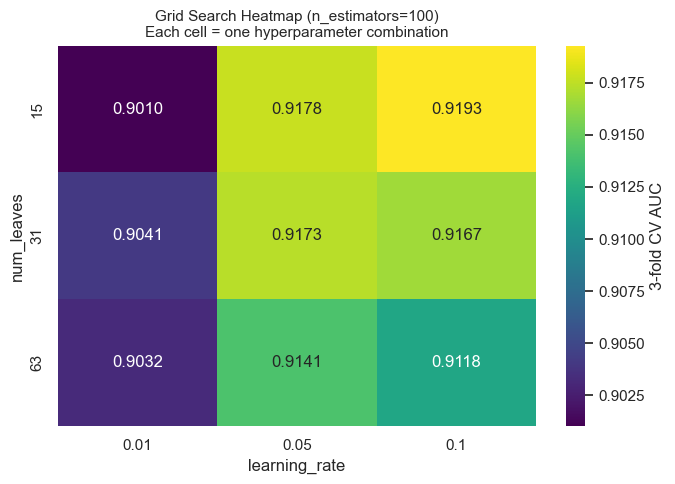

In [5]:
# Visualize the grid as a heatmap: how AUC varies with learning_rate x num_leaves
# (we fix n_estimators at its best value to make a clean 2D picture)
res = pd.DataFrame(grid.cv_results_['params'])
res['cv_auc'] = grid.cv_results_['mean_test_score']
best_n = grid.best_params_['n_estimators']
pivot = (res[res['n_estimators'] == best_n]
         .pivot(index='num_leaves', columns='learning_rate', values='cv_auc'))

plt.figure(figsize=(7, 5))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='viridis', cbar_kws={'label': '3-fold CV AUC'})
plt.title(f'Grid Search Heatmap (n_estimators={best_n})\nEach cell = one hyperparameter combination',
          fontsize=11)
plt.xlabel('learning_rate')
plt.ylabel('num_leaves')
plt.tight_layout()
plt.show()


### How to Read This Chart: Grid Search Heatmap

- **Each cell** is one hyperparameter combination that grid search actually trained and cross-validated.
- **Rows** are `num_leaves` (tree complexity); **columns** are `learning_rate` (step size per tree).
- **Color / number** = the cross-validated AUC for that combination. Brighter (yellow) = better.
- **What to look for:** grid search evaluates the *entire rectangle* — including obviously bad corners.
  Notice how a whole row or column can be uniformly mediocre. Every one of those wasted cells still cost
  a full round of model training. That wasted effort is exactly what the next methods avoid.

> **Key limitation made visual:** grid search spends equal effort everywhere, even in regions that are
> clearly hopeless after the first look.


## Step 5 — Random Search: Try Random Combinations

Here's a surprising result from a famous 2012 paper (Bergstra & Bengio): **random search usually beats
grid search** for the same number of trials. Why?

> **The intuition:** in most problems only a *few* hyperparameters really matter. A grid wastes trials
> testing many values of the unimportant ones. Random search, by sampling each hyperparameter
> independently, ends up trying **more distinct values of the important ones** for the same budget.

Picture tuning two knobs where only one matters. A 3×3 grid tests the important knob at just **3**
values. Nine *random* points test it at up to **9** different values — a much better exploration of the
knob that actually moves the score.

We use scikit-learn's `RandomizedSearchCV`, giving it *distributions* to sample from instead of fixed lists.


In [6]:
from scipy.stats import loguniform, randint

# Instead of fixed lists, we give RANGES to sample from.
# loguniform is used for learning_rate because it spans orders of magnitude (0.005 -> 0.3):
# we care as much about the gap 0.01->0.02 as 0.1->0.2, and log-sampling treats them equally.
param_dist = {
    'learning_rate': loguniform(0.005, 0.3),
    'num_leaves':    randint(8, 128),
    'n_estimators':  randint(100, 600),
    'min_child_samples': randint(5, 60),
}

rand = RandomizedSearchCV(
    LGBMClassifier(random_state=42, verbose=-1),
    param_dist,
    n_iter=18,            # SAME budget as the 18-cell grid, for a fair comparison
    scoring='roc_auc',
    cv=3,
    random_state=42,
    n_jobs=-1
)

t0 = time.time()
rand.fit(X_train, y_train)
rand_time = time.time() - t0
rand_auc = roc_auc_score(y_test, rand.predict_proba(X_test)[:, 1])

print(f"Random search: {rand.n_iter} trials in {rand_time:.1f}s")
print(f"Best params: {rand.best_params_}")
print(f"Random search test AUC: {rand_auc:.4f}  (grid {grid_auc:.4f}, baseline {baseline_auc:.4f})")


Random search: 18 trials in 42.7s
Best params: {'learning_rate': 0.02393565256773262, 'min_child_samples': 56, 'n_estimators': 419, 'num_leaves': 10}
Random search test AUC: 0.9124  (grid 0.9136, baseline 0.9136)


## Step 6 — Bayesian Optimization with Optuna

Grid and random search share one weakness: **they never learn.** Every trial is chosen blindly, ignoring
everything the previous trials revealed. Bayesian optimization fixes this.

### The core idea (in plain English)

> After each trial, Bayesian optimization updates a mental model of "which regions of the hyperparameter
> space look promising," then picks its next trial to balance **exploiting** known-good regions and
> **exploring** uncertain ones. It's the difference between a tourist wandering randomly and a local who
> learns the good neighborhoods as they go.

**Optuna** is the most popular library for this. Its algorithm (called **TPE**, Tree-structured Parzen
Estimator) builds two probability distributions — one for hyperparameters that led to *good* scores and
one for *bad* — and samples where the "good" density is high relative to the "bad."

### How Optuna is structured

- You write an **objective function** that takes a `trial`, *suggests* hyperparameter values from it,
  trains a model, and **returns a score**.
- You create a **study** and call `study.optimize(objective, n_trials=...)`.
- Optuna handles the smart search; you just read off `study.best_params` at the end.


In [7]:
# Split off a validation set from the training data.
# Each Optuna trial trains on X_tr and is scored on X_val — fast (no cross-validation loop).
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42, stratify=y_train
)

def objective(trial):
    # trial.suggest_* asks Optuna for a value; Optuna chooses it intelligently based on past trials.
    params = {
        'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 8, 128),
        'n_estimators':      trial.suggest_int('n_estimators', 100, 600),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 60),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
    }
    model = LGBMClassifier(random_state=42, verbose=-1, **params)
    model.fit(X_tr, y_tr)
    # We MAXIMIZE this returned value (validation AUC).
    return roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])

# A study is one optimization run. direction='maximize' because higher AUC is better.
# sampler seed=42 makes the search reproducible.
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)

t0 = time.time()
study.optimize(objective, n_trials=60, show_progress_bar=False)
optuna_time = time.time() - t0

# Refit on ALL training data with the best params, then score on the held-out test set.
best_model = LGBMClassifier(random_state=42, verbose=-1, **study.best_params)
best_model.fit(X_train, y_train)
optuna_auc = roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1])

print(f"Optuna ran {len(study.trials)} trials in {optuna_time:.1f}s")
print(f"Best validation AUC during search: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")
print(f"Optuna test AUC: {optuna_auc:.4f}  (random {rand_auc:.4f}, grid {grid_auc:.4f}, baseline {baseline_auc:.4f})")


Optuna ran 60 trials in 20.7s
Best validation AUC during search: 0.9175
Best params: {'learning_rate': 0.015345220894359142, 'num_leaves': 18, 'n_estimators': 599, 'min_child_samples': 28, 'subsample': 0.9034853903183965, 'colsample_bytree': 0.7425342506696977}
Optuna test AUC: 0.9147  (random 0.9124, grid 0.9136, baseline 0.9136)


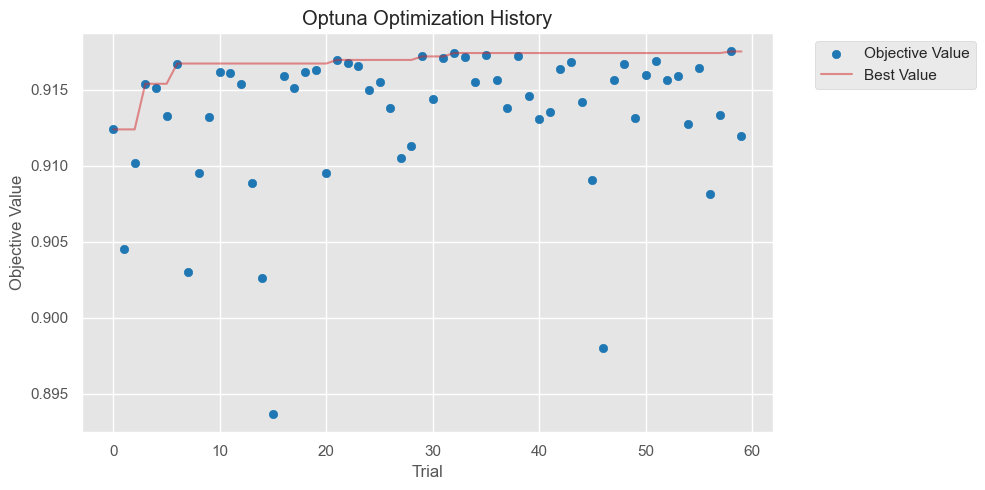

In [8]:
# Optuna's built-in optimization-history plot
ax = plot_optimization_history(study)
ax.set_title('Optuna Optimization History')
plt.tight_layout()
plt.show()


### How to Read This Chart: Optimization History

- **X-axis** = trial number (1st attempt, 2nd attempt, …).
- **Each dot** = the validation score that trial achieved.
- **The red/stepped line** = the *best score found so far* — it can only go up (for maximization) or stay flat.
- **What to look for:**
  - Early trials are scattered — Optuna is **exploring**.
  - The best-so-far line jumps up early, then flattens — Optuna has **zeroed in** on a good region and is
    now making small refinements.
  - A long flat tail means diminishing returns: more trials probably won't help much, so you can stop.

> **This is the payoff of "learning from trials":** the good scores cluster toward the right as Optuna
> uses what it learned, unlike random search where good scores appear (or don't) purely by luck.


## Step 7 — Designing the Search Space

The search is only as good as the ranges you give it. Three practical rules, all visible in our objective:

1. **Use a log scale for anything spanning orders of magnitude.** `learning_rate` from 0.005 to 0.3 is
   sampled with `log=True`, so 0.005→0.01 gets as much attention as 0.1→0.2. Sampling it linearly would
   waste almost all trials on large values.
2. **Give integers integer ranges.** `num_leaves`, `n_estimators`, `min_child_samples` use
   `suggest_int` — no wasted trials on impossible fractional values.
3. **Keep ranges sane, not infinite.** Too-wide ranges waste trials in useless regions; too-narrow ranges
   can exclude the best value. Start from known-reasonable defaults and open up around them.

Categorical knobs use `suggest_categorical`. Here's a tiny illustration of the three suggestion types:


In [9]:
# A throwaway objective just to show the three suggestion styles (we don't optimize anything real here)
def demo_space(trial):
    lr    = trial.suggest_float('lr', 1e-3, 1e-1, log=True)   # continuous, log scale
    depth = trial.suggest_int('depth', 3, 12)                 # integer
    boost = trial.suggest_categorical('boosting', ['gbdt', 'dart', 'goss'])  # pick-one-of
    return lr  # meaningless; we just want to sample the space

demo_study = optuna.create_study(sampler=optuna.samplers.TPESampler(seed=42))
demo_study.optimize(demo_space, n_trials=8, show_progress_bar=False)

print("Eight sampled points from the demo search space:")
for t in demo_study.trials:
    print(f"  lr={t.params['lr']:.4f}  depth={t.params['depth']:2d}  boosting={t.params['boosting']}")


Eight sampled points from the demo search space:
  lr=0.0056  depth=12  boosting=gbdt
  lr=0.0021  depth= 3  boosting=gbdt
  lr=0.0011  depth=12  boosting=gbdt
  lr=0.0023  depth= 6  boosting=gbdt
  lr=0.0167  depth= 4  boosting=goss
  lr=0.0372  depth= 4  boosting=dart
  lr=0.0164  depth= 4  boosting=goss
  lr=0.0414  depth= 6  boosting=dart


## Step 8 — Pruning: Stop Hopeless Trials Early

Some hyperparameter combinations are clearly bad after only a little training. **Pruning** (also called
early stopping *of trials*) detects these and abandons them, freeing the budget for promising ones.

> **Analogy:** if a job candidate bombs the first interview question, you don't finish the whole
> two-hour interview. Pruning gives the model a few "questions" (checkpoints), and if it's doing badly
> compared to other trials at the same checkpoint, it's cut short.

Optuna's `MedianPruner` prunes a trial if, at a given checkpoint, its score is worse than the **median**
of previous trials at that same checkpoint. To use it, our objective **reports intermediate scores** with
`trial.report(...)` and checks `trial.should_prune()`.


In [10]:
def objective_pruning(trial):
    lr         = trial.suggest_float('learning_rate', 0.005, 0.3, log=True)
    num_leaves = trial.suggest_int('num_leaves', 8, 128)
    # Train the model in stages and report progress after each stage so the pruner can judge it.
    for step, n_est in enumerate([50, 100, 200, 400]):
        model = LGBMClassifier(n_estimators=n_est, learning_rate=lr,
                               num_leaves=num_leaves, random_state=42, verbose=-1)
        model.fit(X_tr, y_tr)
        auc = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])
        trial.report(auc, step)              # tell Optuna how this trial is doing at this checkpoint
        if trial.should_prune():             # ...worse than the median so far? give up on it.
            raise optuna.TrialPruned()
    return auc

pruned_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5)  # let 5 trials finish before pruning kicks in
)
pruned_study.optimize(objective_pruning, n_trials=30, show_progress_bar=False)

n_pruned = sum(t.state == optuna.trial.TrialState.PRUNED for t in pruned_study.trials)
n_done   = sum(t.state == optuna.trial.TrialState.COMPLETE for t in pruned_study.trials)
print(f"Of {len(pruned_study.trials)} trials: {n_done} ran to completion, {n_pruned} were pruned early.")
print(f"Those {n_pruned} pruned trials saved us roughly {n_pruned} x (partial training) of wasted compute.")
print(f"Best AUC found: {pruned_study.best_value:.4f}")


Of 30 trials: 13 ran to completion, 17 were pruned early.
Those 17 pruned trials saved us roughly 17 x (partial training) of wasted compute.
Best AUC found: 0.9148


## Step 9 — Which Hyperparameters Actually Mattered?

After a study, Optuna can tell you **how much each hyperparameter influenced the score**. This is gold for
your *next* project: focus tuning effort on the knobs that move the needle and stop wasting trials on the
ones that don't.


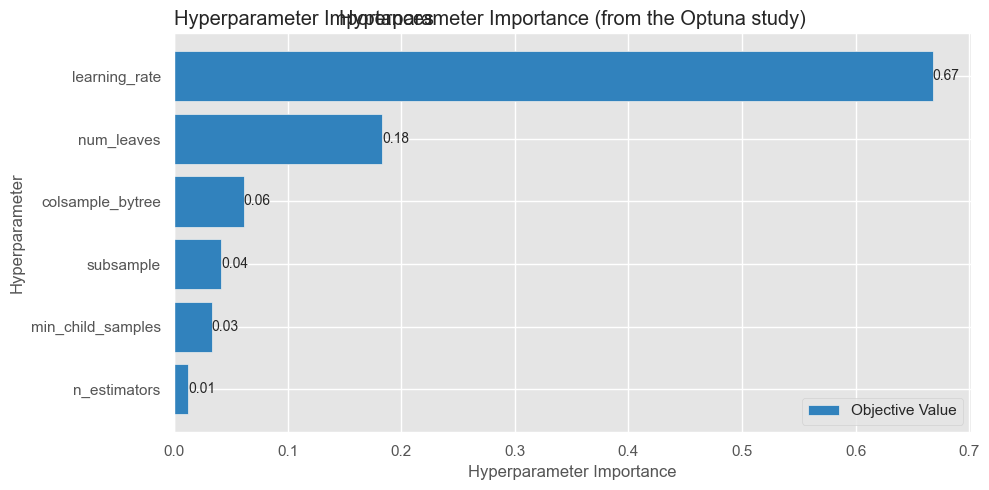

In [11]:
ax = plot_param_importances(study)
ax.set_title('Hyperparameter Importance (from the Optuna study)')
plt.tight_layout()
plt.show()


### How to Read This Chart: Hyperparameter Importance

- **Each bar** is one hyperparameter from our search.
- **Bar length** = its estimated share of influence on the validation score (all bars sum to ~1.0).
- **Longer bar = mattered more.** These are the knobs worth tuning carefully.
- **Tiny bars** are knobs the model barely cared about — on your next run you can fix them at a sensible
  default and spend the trial budget elsewhere.

> **Practical use:** run a broad study once, read this chart, then run a second, tighter study that only
> varies the top 2–3 hyperparameters over narrower ranges. You get better results with fewer trials.


## Step 10 — Apply the Best Params: Tuned vs Default

The whole point was to beat the baseline. Let's line up every method we tried on the **same untouched
test set** and see how much tuning actually bought us.


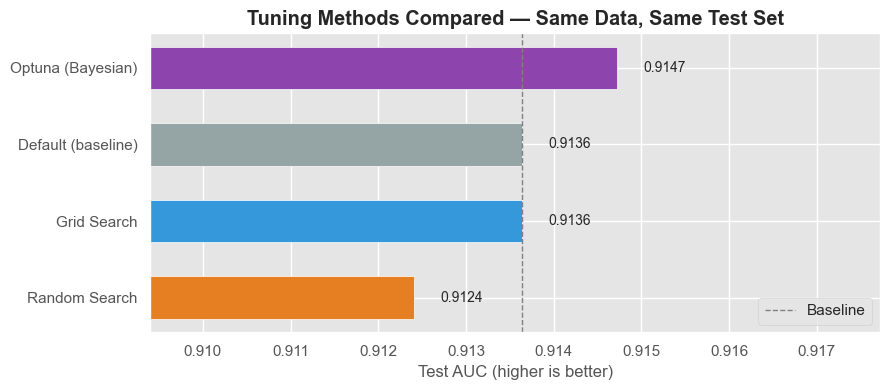

            Method  Test AUC
     Random Search  0.912403
       Grid Search  0.913638
Default (baseline)  0.913640
 Optuna (Bayesian)  0.914720


In [12]:
comparison = pd.DataFrame({
    'Method': ['Default (baseline)', 'Grid Search', 'Random Search', 'Optuna (Bayesian)'],
    'Test AUC': [baseline_auc, grid_auc, rand_auc, optuna_auc],
})
comparison = comparison.sort_values('Test AUC').reset_index(drop=True)

plt.figure(figsize=(9, 4))
colors = ['#95a5a6', '#3498db', '#e67e22', '#8e44ad']
bars = plt.barh(comparison['Method'], comparison['Test AUC'],
                color=[colors[['Default (baseline)', 'Grid Search', 'Random Search',
                               'Optuna (Bayesian)'].index(m)] for m in comparison['Method']],
                edgecolor='white', height=0.55)
for bar, val in zip(bars, comparison['Test AUC']):
    plt.text(val + 0.0003, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=10)
plt.axvline(baseline_auc, color='gray', linestyle='--', linewidth=1, label='Baseline')
plt.xlim(min(comparison['Test AUC']) - 0.003, max(comparison['Test AUC']) + 0.003)
plt.xlabel('Test AUC (higher is better)')
plt.title('Tuning Methods Compared — Same Data, Same Test Set', fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(comparison.to_string(index=False))


### How to Read This Chart: Tuning Methods Compared

- **Each bar** is one method's AUC on the *same* held-out test set — an apples-to-apples comparison.
- **Gray dashed line** = the default-parameters baseline. Everything to the right of it is a real improvement.
- **What to look for:** the gains often look *small* in absolute AUC (a few thousandths), but on a large
  operational dataset even a 0.005 AUC lift can mean meaningfully better ranking of thousands of cases.
  Optuna usually matches or beats grid/random search for the same or smaller budget — that's the whole point.

> **Honesty check:** sometimes tuning barely helps, because good libraries ship with strong defaults.
> Tuning pays off most when (a) the defaults are far from ideal for your data, or (b) small gains matter
> a lot at your scale. Always compare against the default — if tuning doesn't beat it, don't ship the
> extra complexity.


## Step 11 — A Regression Example: Tuning on Ames House Prices

Everything above works for regression too — you just change the **objective** to a regression metric.
Here we tune a `LGBMRegressor` on Ames Housing to **minimize RMSE** (root mean squared error, in dollars).
Note the two differences: `direction='minimize'` and the metric is RMSE, not AUC.


In [13]:
Xh_tr, Xh_val, yh_tr, yh_val = train_test_split(
    Xh_train, yh_train, test_size=0.25, random_state=42
)

def objective_reg(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'num_leaves':    trial.suggest_int('num_leaves', 8, 128),
        'n_estimators':  trial.suggest_int('n_estimators', 100, 800),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 60),
        'subsample':     trial.suggest_float('subsample', 0.6, 1.0),
    }
    model = LGBMRegressor(random_state=42, verbose=-1, **params)
    model.fit(Xh_tr, yh_tr)
    return np.sqrt(mean_squared_error(yh_val, model.predict(Xh_val)))  # RMSE — lower is better

study_reg = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study_reg.optimize(objective_reg, n_trials=50, show_progress_bar=False)

# Default baseline vs tuned, on the untouched Ames test set
default_reg = LGBMRegressor(random_state=42, verbose=-1).fit(Xh_train, yh_train)
default_rmse = np.sqrt(mean_squared_error(yh_test, default_reg.predict(Xh_test)))
tuned_reg = LGBMRegressor(random_state=42, verbose=-1, **study_reg.best_params).fit(Xh_train, yh_train)
tuned_rmse = np.sqrt(mean_squared_error(yh_test, tuned_reg.predict(Xh_test)))

print(f"Default LightGBM test RMSE: ${default_rmse:,.0f}")
print(f"Tuned   LightGBM test RMSE: ${tuned_rmse:,.0f}")
print(f"Improvement: ${default_rmse - tuned_rmse:,.0f} lower error per house on average")
print(f"Best params: {study_reg.best_params}")


Default LightGBM test RMSE: $29,310
Tuned   LightGBM test RMSE: $28,731
Improvement: $579 lower error per house on average
Best params: {'learning_rate': 0.011501448153350512, 'num_leaves': 36, 'n_estimators': 617, 'min_child_samples': 29, 'subsample': 0.6371284236601402}


## Step 12 — Summary and Key Takeaways

### The three methods at a glance

| Method | How it picks trials | Best for | Weakness |
|--------|--------------------|----------|----------|
| **Grid Search** | Every combination on a fixed grid | 1–3 hyperparameters, small grids | Explodes combinatorially; wastes trials |
| **Random Search** | Random samples from ranges | A quick, strong baseline; 3–6 knobs | Still doesn't learn from past trials |
| **Bayesian (Optuna)** | Learns from past trials, searches smartly | Many hyperparameters; expensive models | Slightly more setup; sequential by nature |

### Decision guide

```
How many hyperparameters are you tuning?
│
├─ 1–2, few values each      → Grid Search (simple, exhaustive, easy to explain)
│
├─ 3–6, want a fast baseline → Random Search (great effort-to-reward ratio)
│
└─ Many knobs / costly model → Optuna (Bayesian) + Pruning
                                 → run broad, read param-importance, then run tight
```

### Common mistakes to avoid

1. **Tuning on the test set.** Never let the search see your final test data. Use a separate validation
   split (or cross-validation) *inside* the objective; keep the test set for the one final score.
2. **Linear-scaling a log-scale parameter.** `learning_rate`, regularization strengths, and similar
   knobs span orders of magnitude — always sample them with `log=True`.
3. **Ignoring strong defaults.** Modern libraries ship good defaults. Always compare tuned vs default; if
   tuning doesn't beat the baseline, ship the simpler model.
4. **Too few trials with too wide a space.** A huge search space needs many trials. Either narrow the
   ranges or raise `n_trials`.
5. **Not using pruning on expensive models.** If each trial takes minutes, pruning hopeless ones early
   can cut total tuning time by half or more.

### What's next?

Now that you can tune any model, the natural next steps in this series are **k-NN & SVM** (models that
are *very* sensitive to their hyperparameters), **model interpretability** (explaining the tuned model),
and **evaluation & threshold selection** (turning a tuned model into good decisions).

---

*Notebook by Shivani Bokka — Dive Deeper into Supervised Learning Series*
